# Homework 12 -- APPM 4600
## Problem 1
### Part (a)

In [33]:
def gaussian_elimination(A, b):
    # Needs numpy vectors
    A = A.copy().astype(float)
    b = b.copy().astype(float)
    n = len(b)

    # Forward elimination
    for k in range(n - 1):
        for i in range(k + 1, n):
            factor = A[i, k] / A[k, k]
            A[i, k:] -= factor * A[k, k:]
            b[i] -= factor * b[k]

    return A, b

def back_substitution(U, b):
    # Back sub UTM * b 
    n = len(b)
    x = np.zeros(n)

    for i in range(n-1, -1, -1):
        x[i] = (b[i] - np.dot(U[i, i+1:], x[i+1:] )) / U[i, i]
    
    return x

### Part 1b

In [34]:
import numpy as np

n = 10

i = np.arange(n).reshape(-1, 1)
j = np.arange(n).reshape(1, -1)
A = np.cos(( i * (j + 0.5) * np.pi ) / n)

x_true = np.arange(1, n + 1)

# Compute b
b = A @ x_true

# Solve using Gaussian elimination
U, b_mod = gaussian_elimination(A, b)
x_comp = back_substitution(U, b_mod)

# Print augmented matrix
print("Upper triangular matrix [U | b]:")
aug = np.hstack([U, b_mod.reshape(-1,1) ])
print(np.round(aug, 2))

# Entrywise error
error = np.abs(x_comp - x_true)
print("\nEntrywise error:")
print(error)

Upper triangular matrix [U | b]:
[[ 1.00000e+00  1.00000e+00  1.00000e+00  1.00000e+00  1.00000e+00
   1.00000e+00  1.00000e+00  1.00000e+00  1.00000e+00  1.00000e+00
   5.50000e+01]
 [ 0.00000e+00 -1.00000e-01 -2.80000e-01 -5.30000e-01 -8.30000e-01
  -1.14000e+00 -1.44000e+00 -1.69000e+00 -1.88000e+00 -1.98000e+00
  -7.45000e+01]
 [ 0.00000e+00  0.00000e+00  1.00000e-01  4.70000e-01  1.22000e+00
   2.40000e+00  3.88000e+00  5.42000e+00  6.70000e+00  7.42000e+00
   2.27630e+02]
 [ 0.00000e+00  0.00000e+00  0.00000e+00 -2.40000e-01 -1.34000e+00
  -4.14000e+00 -9.01000e+00 -1.53200e+01 -2.14000e+01 -2.51600e+01
  -6.62310e+02]
 [ 0.00000e+00  0.00000e+00  0.00000e+00  0.00000e+00  8.00000e-01
   5.05000e+00  1.63500e+01  3.55800e+01  5.75700e+01  7.25400e+01
   1.67696e+03]
 [ 0.00000e+00  0.00000e+00  0.00000e+00  0.00000e+00  0.00000e+00
  -3.16000e+00 -1.99700e+01 -6.14500e+01 -1.20600e+02 -1.65990e+02
  -3.39563e+03]
 [ 0.00000e+00  0.00000e+00 -0.00000e+00  0.00000e+00  0.00000e+00


### Part (c)

In [35]:
import time

n = 1000

A = np.random.randn(n, n)
x_true = np.arange(1, n + 1)
b = A @ x_true

start = time.perf_counter()

U, b_mod = gaussian_elimination(A, b)
x_comp = back_substitution(U, b_mod)

end = time.perf_counter()

time_ge = end - start
error_ge = np.linalg.norm(x_comp - x_true)

print("\nPart (c):")
print(f"Time (gaussian elimination): {time_ge:.4f} (s)")
print(f"Error (2-norm): {error_ge:.4e}")


Part (c):
Time (gaussian elimination): 0.8210 (s)
Error (2-norm): 1.0553e-06


### Part (d)

In [36]:
start = time.perf_counter()

x_np = np.linalg.solve(A, b)

end = time.perf_counter()

time_np = end - start
error_np = np.linalg.norm(x_np - x_true)

print("\nPart (d):")
print(f"Time (numpy solve): {time_np:.4f} (s)")
print(f"Error (2-norm): {error_np:.4e}")


Part (d):
Time (numpy solve): 0.0106 (s)
Error (2-norm): 4.0522e-09


We notice that the Numpy method is not only 100x faster, but also has 3 more digits of accuracy! This is because our method, with the loops, is $O(n^3)$, whereas the built in solver clearly has a much better algorithm and is significantly more numerically stable.

## Problem 2

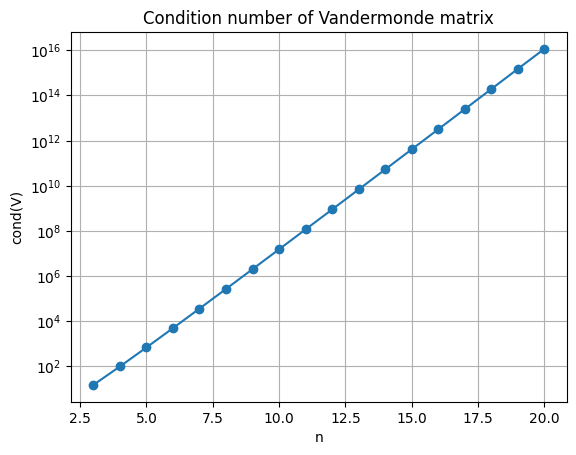

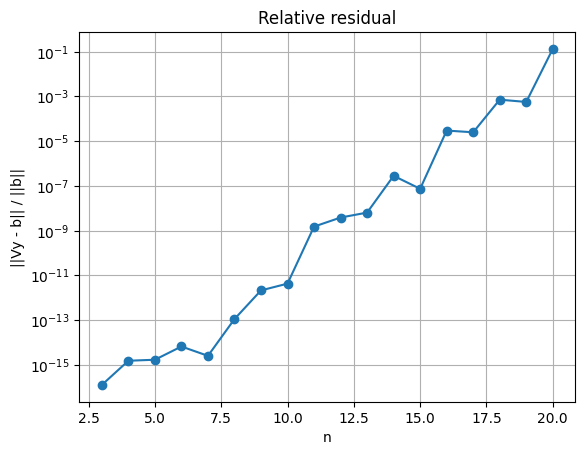

In [37]:
# Part (a) and (b)
import matplotlib.pyplot as plt

rng = np.random.default_rng()

# Store results
ns = np.arange(3, 21)
conds = []
residuals = []

for n in ns:
    # Equally spaced nodes in [0, 1]
    x = np.linspace(0, 1, n)

    V = np.vander(x, N=n, increasing = True) # Vandermonde

    conds.append(np.linalg.cond(V)) # Conditioning #

    # Random RHS
    b = rng.random(n)

    y = np.linalg.solve(V, b)

    # Relative residual
    res = np.linalg.norm( V @ y - b) / np.linalg.norm(b)
    residuals.append(res)

# Plot conditioning
plt.figure()
plt.semilogy(ns, conds, marker='o')
plt.title("Condition number of Vandermonde matrix")
plt.xlabel("n")
plt.ylabel("cond(V)")
plt.grid()

# Plot residual
plt.figure()
plt.semilogy(ns, residuals, marker='o')
plt.title("Relative residual")
plt.xlabel("n")
plt.ylabel("||Vy - b|| / ||b||")
plt.grid()



We note that the condition number grows exponentially with $n$. This is becuase the Vandermonde matricies are known to be extremely ill-conditioned. 

The relative residual appears to be decreasing, but this is a misleading result. The solution $y$ can be very innacurate, even if $$||Vy-b||$$ is small. This is because the $\text{relative error} \lesssim \kappa (V) \times \text{relative residual}$, so with a large condition number, we get amplified error.

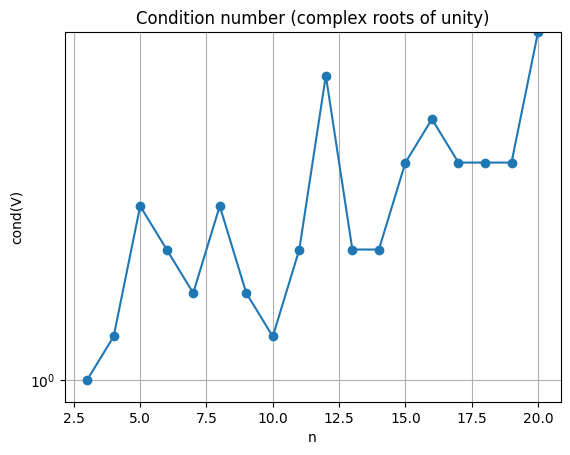

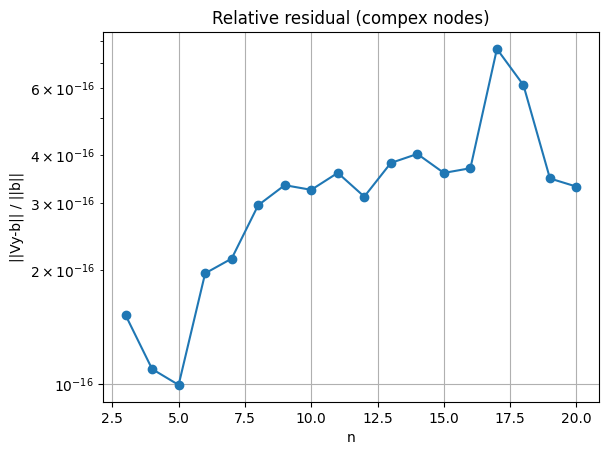

In [38]:
# Part (c)
conds_complex = []
residuals_complex = []

for n in ns:
    j = np.arange(n)
    x = np.exp(-2j * np.pi * j / n)

    V = np.vander(x, N=n, increasing=True)

    conds_complex.append(np.linalg.cond(V))

    b = rng.random(n) + 1j * rng.random(n)

    y = np.linalg.solve(V, b)

    res = np.linalg.norm(V @ y - b) / np.linalg.norm(b)
    residuals_complex.append(res)

# Plot condition number
plt.figure()
plt.semilogy(ns, conds_complex, marker='o')
plt.title("Condition number (complex roots of unity)")
plt.xlabel("n")
plt.ylabel("cond(V)")
plt.grid()

# residual
plt.figure()
plt.semilogy(ns, residuals_complex, marker='o')
plt.title("Relative residual (compex nodes)")
plt.xlabel("n")
plt.ylabel("||Vy-b|| / ||b||")
plt.grid()

plt.show()

Here, the condition number is approximately 1, with very very small residuals, meaning the solutions are stable. This is becuase this matrix is pretty much the Discrete Fourier Transform matrix, with nearly orthogonal columns, and the matrix is almost unitary.

## Problem 3

Part(a): Correctness test on a small system
Method          | Error ||x - x_true||
----------------------------------------
Direct solve    |             2.31e-16
LU solve            |             2.31e-16
Inverse solve  |             6.36e-17

Part (b): Timing and error experiment
Running n = 1000 ...
Running n = 2000 ...
Running n = 3000 ...
Running n = 4000 ...
Running n = 5000 ...

Timing results (seconds):
n      |     Direct |         LU |    Inverse
---------------------------------------------
1000   |      0.011 |      0.009 |      0.023
2000   |      0.060 |      0.027 |      0.102
3000   |      0.173 |      0.113 |      0.265
4000   |      0.261 |      0.245 |      0.487
5000   |      0.704 |      0.509 |      1.180

Relative error:
n      |     Direct |         LU |    Inverse
---------------------------------------------
1000   |   2.96e-13 |   2.96e-13 |   7.91e-13
2000   |   3.36e-13 |   3.36e-13 |   2.07e-12
3000   |   2.44e-12 |   2.44e-12 |   7.68e-12
4000   |   2.42e

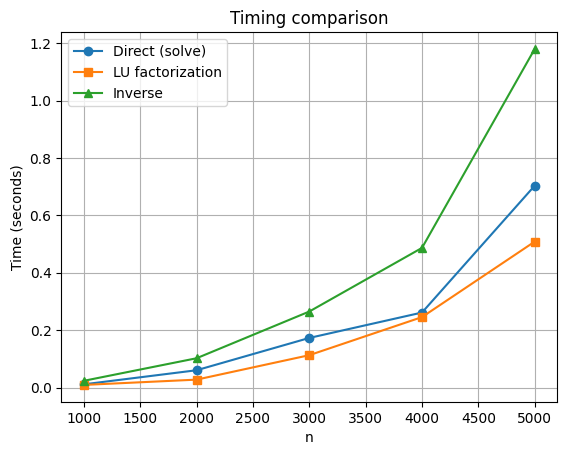

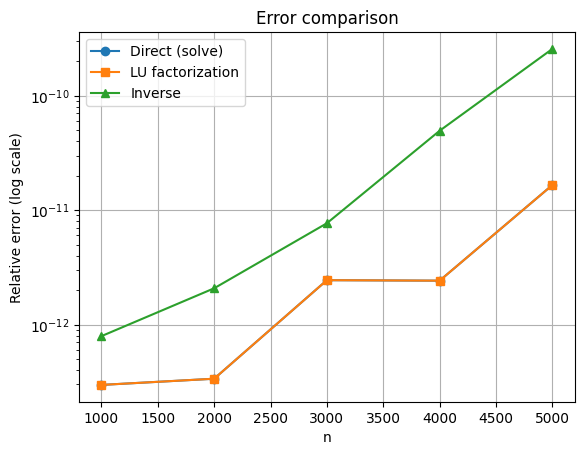

In [39]:
from scipy.linalg import solve, lu_factor, lu_solve, inv

# Part (a)
def solve_direct(A, b):
    return solve(A, b)

def solve_lu(A, b):
    lu, piv = lu_factor(A)
    return lu_solve((lu, piv), b)

def solve_inverse(A, b):
    return inv(A) @ b

# Test correctness
def test_small():
    print("Part(a): Correctness test on a small system")
    n = 5
    rng = np.random.default_rng(0)

    A = rng.standard_normal((n, n))
    x_true = rng.standard_normal(n)
    b = A @ x_true

    x1 = solve_direct(A, b)
    x2 = solve_lu(A, b)
    x3 = solve_inverse(A, b)

    print(f"{'Method':<15} | {'Error ||x - x_true||':>20}")
    print("-" * 40)
    print(f"{'Direct solve':<15} | {np.linalg.norm(x1 - x_true):>20.2e}")
    print(f"{'LU solve':<15}     | {np.linalg.norm(x2 - x_true):>20.2e}")
    print(f"{'Inverse solve':<15}| {np.linalg.norm(x3 - x_true):>20.2e}")
    print()

# Part (b)
def run_experiment():
    print("Part (b): Timing and error experiment")

    rng = np.random.default_rng(1)

    sizes = np.arange(1000, 5001, 1000)

    times_direct = []
    times_lu = []
    times_inv = []

    errors_direct = []
    errors_lu = []
    errors_inv = []

    for n in sizes:
        print(f"Running n = {n} ...")

        A = rng.standard_normal((n, n))
        x_true = rng.standard_normal(n)
        b = A @ x_true

        # Direct solve
        t0 = time.perf_counter()
        x = solve_direct(A, b)
        t1 = time.perf_counter()
        times_direct.append(t1 - t0)
        errors_direct.append(np.linalg.norm(x - x_true) / np.linalg.norm(x_true))

        # LU solve 
        t0 = time.perf_counter()
        x = solve_lu(A, b)
        t1 = time.perf_counter()
        times_lu.append(t1 - t0)
        errors_lu.append(np.linalg.norm(x - x_true) / np.linalg.norm(x_true))

        # Inverse solve
        t0 = time.perf_counter()
        x = solve_inverse(A, b)
        t1 = time.perf_counter()
        times_inv.append(t1 - t0)
        errors_inv.append(np.linalg.norm(x - x_true) / np.linalg.norm(x_true))

    # Results table and plots done by Claude

    # ----------------------------
    # Print results table
    # ----------------------------
    print("\nTiming results (seconds):")
    print(f"{'n':<6} | {'Direct':>10} | {'LU':>10} | {'Inverse':>10}")
    print("-" * 45)
    for i, n in enumerate(sizes):
        print(f"{n:<6} | {times_direct[i]:>10.3f} | {times_lu[i]:>10.3f} | {times_inv[i]:>10.3f}")

    print("\nRelative error:")
    print(f"{'n':<6} | {'Direct':>10} | {'LU':>10} | {'Inverse':>10}")
    print("-" * 45)
    for i, n in enumerate(sizes):
        print(f"{n:<6} | {errors_direct[i]:>10.2e} | {errors_lu[i]:>10.2e} | {errors_inv[i]:>10.2e}")

    # ----------------------------
    # Plot timing
    # ----------------------------
    plt.figure()
    plt.plot(sizes, times_direct, 'o-', label='Direct (solve)')
    plt.plot(sizes, times_lu, 's-', label='LU factorization')
    plt.plot(sizes, times_inv, '^-', label='Inverse')
    plt.xlabel('n')
    plt.ylabel('Time (seconds)')
    plt.title('Timing comparison')
    plt.legend()
    plt.grid()

    # ----------------------------
    # Plot error
    # ----------------------------
    plt.figure()
    plt.semilogy(sizes, errors_direct, 'o-', label='Direct (solve)')
    plt.semilogy(sizes, errors_lu, 's-', label='LU factorization')
    plt.semilogy(sizes, errors_inv, '^-', label='Inverse')
    plt.xlabel('n')
    plt.ylabel('Relative error (log scale)')
    plt.title('Error comparison')
    plt.legend()
    plt.grid()

    plt.show()

test_small()
run_experiment()


We see that all methods are roughly $O(n^3)$, but LU solve is the fastest, and inverse solving is the slowest. However, LU factorization does slightly worse than the direct inverse method in error. It is hard to see, but the solver method is hidden behind the orange LU factorizaiton method in the Error comparison table, meaning they do exactly the same here. 